In [41]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 7.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [18]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.integrate import solve_ivp
from scipy.signal import StateSpace, lsim
from control import ss2tf, bode_plot, ss, forced_response

## Questão B
Utilizando o ponto de equilíbrio fornecido, encontre a Representação
em Espaços de Estados (REE) da dinâmica dos desvios (δx˙ = Aδx+Bδu, δy = Cδx+
Dδu ou a forma discreta equivalente). Calcule as matrizes Jacobianas avaliadas no
ponto de equilíbrio e apresente as matrizes (A, B, C, D) resultantes.

In [2]:
# Definição das variáveis simbólicas
x1, x2, u = sp.symbols('x1 x2 u')
x = sp.Matrix([x1, x2])  # Vetor de estados

# Equações de estado (não lineares)
f1 = (
    16.9*u
    - 136.1*x1
    - 823.6*x2
    + 19.3*x1**2 * x2
    - 1.229*x1 * sp.cos(x2)
    - 1.229*x2 * sp.cos(x2)
    + 19.3*x1**3
)
f2 = (
    53.13*x1
    - 13.68*u
    + 57.53*x2
    + 3.514*x1**2 * x2
    - 0.2167*x1 * sp.cos(x2)
    - 0.2167*x2 * sp.cos(x2)
    + 3.514*x1**3
)
f = sp.Matrix([f1, f2])  # Vetor de equações de estado

# Equação de saída
y = -0.8933*x1**3 - 0.8747*x2*x1**2 + 39.32*x1 + 48.59*x2

# Cálculo das Jacobianas
A = f.jacobian(x)         # df/dx
B = f.jacobian([u])       # df/du
C = sp.Matrix([y]).jacobian(x)  # dy/dx
D = sp.Matrix([y]).jacobian([u])  # dy/du

# Ponto de equilíbrio
equilibrium = {x1: 0, x2: 0, u: 0}

# Avaliação no ponto de equilíbrio
A_eq = A.subs(equilibrium).evalf()
B_eq = B.subs(equilibrium).evalf()
C_eq = C.subs(equilibrium).evalf()
D_eq = D.subs(equilibrium).evalf()

# Impressão dos resultados
print("Matriz A (df/dx) no ponto de equilíbrio:")
sp.pprint(A_eq)

print("\nMatriz B (df/du) no ponto de equilíbrio:")
sp.pprint(B_eq)

print("\nMatriz C (dy/dx) no ponto de equilíbrio:")
sp.pprint(C_eq)

print("\nMatriz D (dy/du) no ponto de equilíbrio:")
sp.pprint(D_eq)

Matriz A (df/dx) no ponto de equilíbrio:
⎡-137.329  -824.829⎤
⎢                  ⎥
⎣52.9133   57.3133 ⎦

Matriz B (df/du) no ponto de equilíbrio:
⎡ 16.9 ⎤
⎢      ⎥
⎣-13.68⎦

Matriz C (dy/dx) no ponto de equilíbrio:
[39.32  48.59]

Matriz D (dy/du) no ponto de equilíbrio:
[0]


In [3]:
A_eq

Matrix([
[-137.329, -824.829],
[ 52.9133,  57.3133]])

In [4]:
type(A_eq)

sympy.matrices.dense.MutableDenseMatrix

## Questão C
1. Determine a função de transferência do sistema, G(s) = Y (s)/U(s) ou G(z) =
Y (z)/U(z).
2. Analise a estabilidade interna do sistema com base nos autovalores da matriz
A.
3. Analise a estabilidade entrada-saída (BIBO) com base nos polos da função de
transferência G(s) ou G(z). Comente a relação entre os autovalores de A e os
polos de G.

### 1. Determine a função de transferência do sistema, G(s) = Y (s)/U(s) ou G(z) = Y (z)/U(z).

In [5]:
# Definição das variáveis simbólicas
s = sp.symbols('s')

# Identidade
I = sp.eye(2)

# Cálculo da função de transferência: G(s) = C * (sI - A)^(-1) * B + D
G_s = C_eq * (s*I - A_eq).inv() * B_eq + D_eq

# Simplificar
G_s = sp.simplify(G_s[0])

# Mostrar resultado
print("Função de transferência G(s) = Y(s)/U(s):\n")
G_s

Função de transferência G(s) = Y(s)/U(s):



(357755.1362435 - 0.203200000000152*s)/(1.0*s**2 + 80.0157*s + 35773.64615)

### 2. Analise a estabilidade interna do sistema com base nos autovalores da matriz A.

#### Resposta: 
Com base nos autovalores da matriz A, é possível concluir que o sistema é internamente estável, pois todos os autovalores tem parte real negativa (estão no semipleano esquerdo do plano complexo).

In [6]:
autovalores = A_eq.eigenvals()

print("Autovalores da matriz A (estabilidade interna):")

for val, multiplicidade in autovalores.items():
    print(f"{val.evalf()} (multiplicidade {multiplicidade})")

Autovalores da matriz A (estabilidade interna):
-40.00785 - 184.859454960728*I (multiplicidade 1)
-40.00785 + 184.859454960728*I (multiplicidade 1)


In [7]:
autovalores

{-40.00785 - 184.859454960728*I: 1, -40.00785 + 184.859454960728*I: 1}

### 3. Analise a estabilidade entrada-saída (BIBO) com base nos polos da função de transferência G(s) ou G(z). Comente a relação entre os autovalores de A e os polos de G.

#### Resposta:
Analisando os polos da função G(s), conclui-se que que o sistema é BIBO estável. 
Além disso, os polos de G(s) são os mesmos que os autovalores de A, exceto quando há cancelamentos por zeros.

## Questão D
1. Simulação 1 (Pequeno Desvio): Partindo da condição inicial x(0) = xeq, e amplitude do degrau δu = 0,01.
2. Simulação 2 (Grande Desvio - Se não ver grande diferença nas respostas, aumente o valor do desvio): Partindo da condição inicial x(0) = xeq, eamplitude do degrau (aumente se necessário) δu = 2.
3. Para cada simulação, plote o sinal de saída do sistema não-linear original e do sistema linearizado no mesmo gráfico. Discuta e analise as diferenças, explicando por que o modelo linearizado se aproxima bem (ou falha em se aproximar) do comportamento não-linear em cada caso.

In [8]:
# Tempo de simulação
t = np.linspace(0, 2, 1000)

In [9]:
# -------------------------
# DEFINIÇÃO DO SISTEMA
# -------------------------

# Sistema não linear (dx/dt)
def nonlinear_system(t, x, u_func):
    x1, x2 = x
    u = u_func(t)

    dx1 = (
        16.9 * u
        - 136.1 * x1
        - 823.6 * x2
        + 19.3 * x1**2 * x2
        - 1.229 * x1 * np.cos(x2)
        - 1.229 * x2 * np.cos(x2)
        + 19.3 * x1**3
    )
    dx2 = (
        53.13 * x1
        - 13.68 * u
        + 57.53 * x2
        + 3.514 * x1**2 * x2
        - 0.2167 * x1 * np.cos(x2)
        - 0.2167 * x2 * np.cos(x2)
        + 3.514 * x1**3
    )
    return [dx1, dx2]

# Saída do sistema não linear
def nonlinear_output(x):
    x1, x2 = x
    return -0.8933 * x1**3 - 0.8747 * x2 * x1**2 + 39.32 * x1 + 48.59 * x2

# Sistema linearizado (matrizes A, B, C, D)
A = A_eq 
B = B_eq 
C = C_eq 
D = D_eq

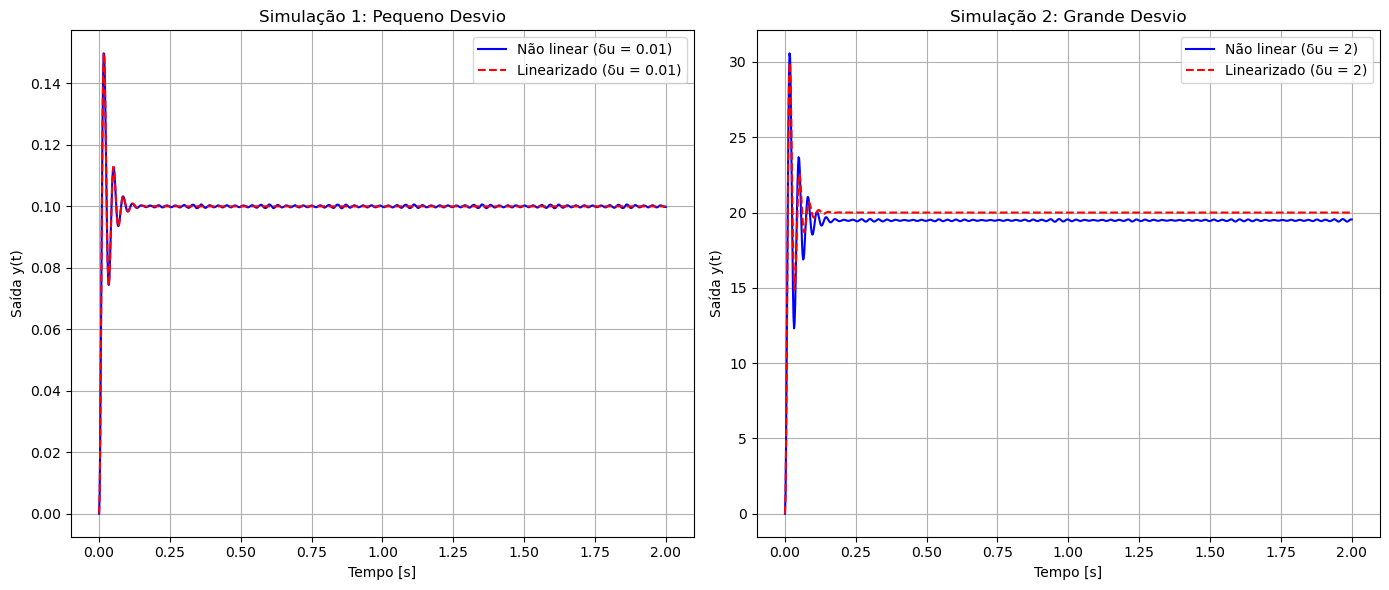

In [10]:
# -------------------------
# FUNÇÕES DE SIMULAÇÃO
# -------------------------

# Simula o sistema não linear
def simulate_nonlinear(u_func):
    sol = solve_ivp(fun=lambda t, x: nonlinear_system(t, x, u_func),
                    t_span=(t[0], t[-1]), y0=[0, 0], t_eval=t, method='RK45')
    y = np.array([nonlinear_output(xi) for xi in sol.y.T])
    return sol.t, y

# Simula o sistema linearizado
def simulate_linear(u_val):
    U = np.ones_like(t) * u_val
    sys = StateSpace(A, B, C, D)
    tout, yout, _ = lsim(sys, U=U, T=t)
    return tout, yout

# -------------------------
# SIMULAÇÕES
# -------------------------

# Pequeno desvio: δu = 0.01
delta_u_small = 0.01
u_small = lambda t: delta_u_small
t_nl1, y_nl1 = simulate_nonlinear(u_small)
t_lin1, y_lin1 = simulate_linear(delta_u_small)

# Grande desvio: δu = 2.0
delta_u_large = 2.0
u_large = lambda t: delta_u_large
t_nl2, y_nl2 = simulate_nonlinear(u_large)
t_lin2, y_lin2 = simulate_linear(delta_u_large)

# -------------------------
# PLOT
# -------------------------

plt.figure(figsize=(14, 6))

# Simulação 1: pequeno desvio
plt.subplot(1, 2, 1)
plt.plot(t_nl1, y_nl1, label='Não linear (δu = 0.01)', color='blue')
plt.plot(t_lin1, y_lin1, '--', label='Linearizado (δu = 0.01)', color='red')
plt.title('Simulação 1: Pequeno Desvio')
plt.xlabel('Tempo [s]')
plt.ylabel('Saída y(t)')
plt.grid()
plt.legend()

# Simulação 2: grande desvio
plt.subplot(1, 2, 2)
plt.plot(t_nl2, y_nl2, label='Não linear (δu = 2)', color='blue')
plt.plot(t_lin2, y_lin2, '--', label='Linearizado (δu = 2)', color='red')
plt.title('Simulação 2: Grande Desvio')
plt.xlabel('Tempo [s]')
plt.ylabel('Saída y(t)')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

### 3. Para cada simulação, plote o sinal de saída do sistema não-linear original e do sistema linearizado no mesmo gráfico. Discuta e analise as diferenças, explicando por que o modelo linearizado se aproxima bem (ou falha em se aproximar) do comportamento não-linear em cada caso.

**Resposta**:

**Simulação 1**: As respostas dos dois sistemas (não linear e linearizado) coincidem quase completamente. Isso ocorre porque a linearização é uma boa aproximação local: para pequenas variações em torno do ponto de equilíbrio x = [0, 0], as não linearidades têm impacto desprezível.

**Simulação 2**: Há uma diferença significativa entre as curvas dos dois sistemas. O sistema não linear responde de forma mais lenta e com maior distorção, enquanto que o sistema linearizado responde com rapidez e sem deformações.

Portanto, por meio da análise das duas simulações, percebe-se que a linearização funciona bem apenas localmente, isto é, próximo do ponto de equilíbrio. Para desvios grandes, os termos não lineares como x1²x2, x1³, e cos(x2) dominam a dinâmica, tornando o modelo linear inadequado. Assim, o modelo linearizado é confiável apenas para simulações com pequenas perturbações.

## Questão E

1. Gere o Diagrama de Bode para o seu sistema linearizado G(s) ou G(z). Você pode fazer uso dos comandos tf, bode do MATLAB, ou as funções tf, bode_plot do pacote control em Python para fazer isso.
2. Marque no Diagrama de Bode as posições exatas das três frequências senoidais de teste fornecidas na sua ficha técnica. Para cada uma, indique o valor da magnitude (em dB) e da fase (em graus) no ponto correspondente sobre o Diagrama de Bode obtido no passo anterior.
3. Simule o sistema linear com cada uma das três entradas senoidais fornecidas na sua ficha técnica.
4. Para cada uma das três simulações com entrada senoidal, realize a seguinte análise comparativa:

    - (a) Simule o sistema linear local, usando como entrada os sinais senoidais apontados na sua ficha técnica. Tome cuidado para usar um passo de integração (se o seu sistema for em Tempo Contínuo) que contenha pelo menos 100 amostras por peréodo do sinal de entrada oscilatério. Note que os períodos variam bastante, e isso é especialmente importante para períodos curtos (frequências altas).
    - (b) A partir do gráfico da resposta temporal da simulação com o sistema linear local, meça a amplitude da saída em regime permanente (Aout) e divida pela amplitude do sinal de entrada em regime permanente para obter o ganho linear para cada um dos sinais de entrada de frequências diferentes. Em seguida, verifique a defasagem (∆ϕ) do sinal de saída em relação ao sinal de entrada, em regime permanente, também para cada caso.
    - (c) Construa uma tabela que compare, para cada frequˆencia na sua ficha técnica, os resultados teóricos (mostrados no Diagrama de Bode) com os resultados práticos (obtidos observando-se os resultados da simulação temporal), comentando brevemente se os valores são consistentes.

### 1. Gere o Diagrama de Bode para o seu sistema linearizado G(s) ou G(z). Você pode fazer uso dos comandos tf, bode do MATLAB, ou as funções tf, bode_plot do pacote control em Python para fazer isso.


/home/matheusvf/anaconda3/lib/python3.11/site-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


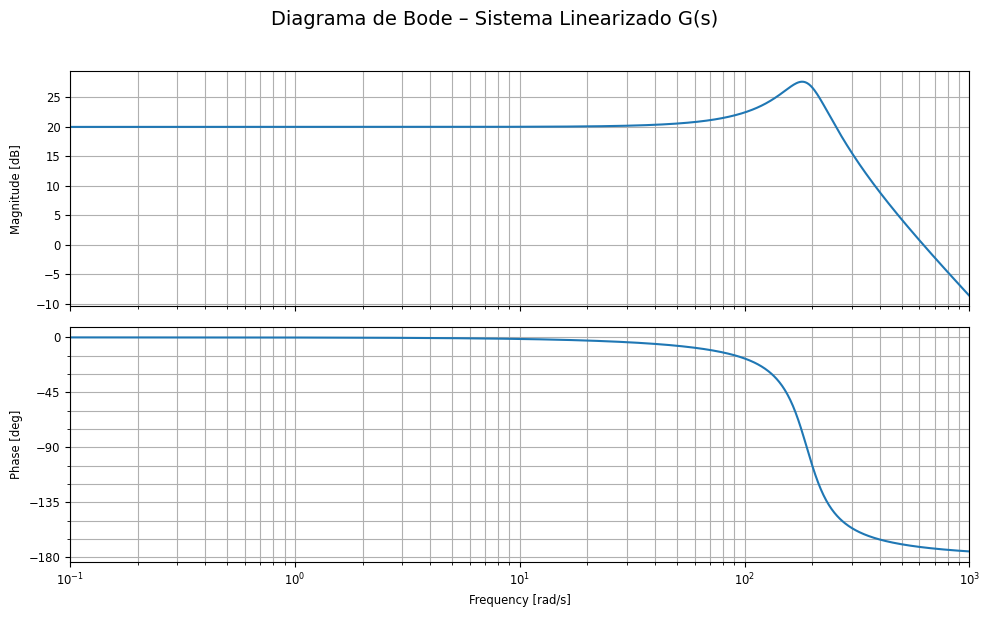

In [11]:
# Criar o sistema no formato espaço de estados
system_ss = ss(A, B, C, D)

# Gerar o Diagrama de Bode
plt.figure(figsize=(10, 6))
mag, phase, omega = bode_plot(system_ss, dB=True, Hz=False, omega_limits=(1e-1, 1e3), plot=True)
plt.suptitle("Diagrama de Bode – Sistema Linearizado G(s)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2. Marque no Diagrama de Bode as posições exatas das três frequências senoidais de teste fornecidas na sua ficha técnica. Para cada uma, indique o valor da magnitude (em dB) e da fase (em graus) no ponto correspondente sobre o Diagrama de Bode obtido no passo anterior.

/home/matheusvf/anaconda3/lib/python3.11/site-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


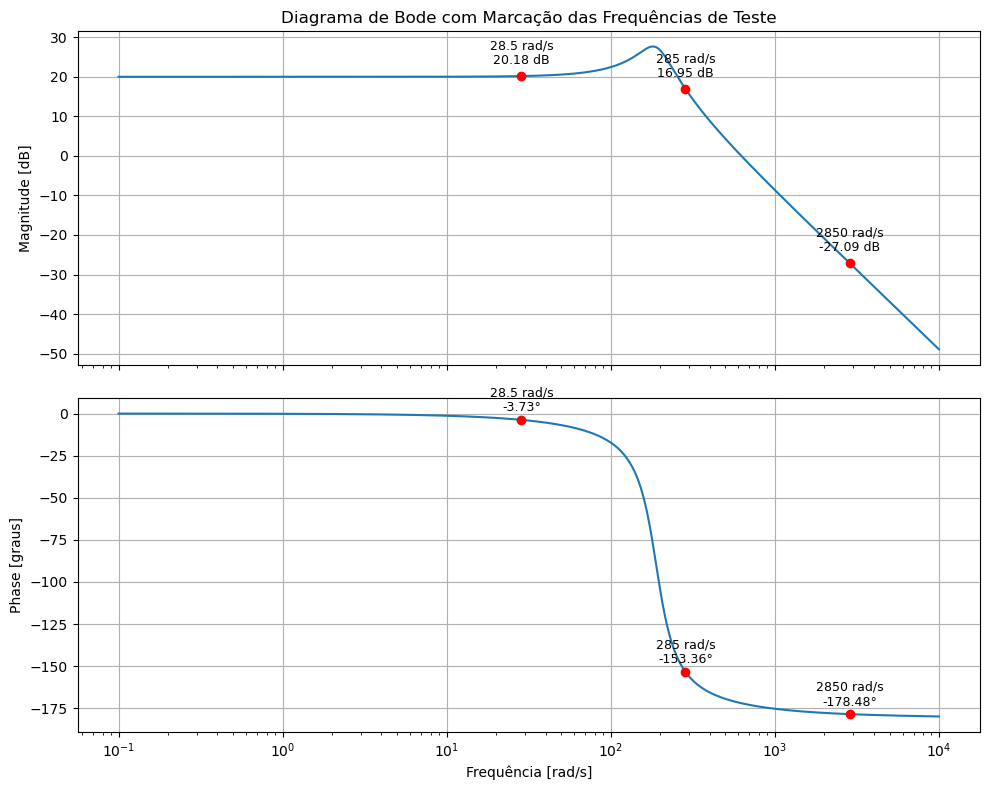

In [12]:
# Frequências senoidais (rad/s)
frequencias = [28.5, 285, 2850]

omega = np.logspace(-1, 4, 1000)
mag, phase, omega_bode = bode_plot(system_ss, omega=omega, dB=True, Hz=False, deg=True, plot=False)

# Interpolação dos valores nas frequências de interesse
mag_db = np.interp(frequencias, omega_bode, 20 * np.log10(mag))
phase_deg = np.interp(frequencias, omega_bode, np.degrees(phase))

# Plot
fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Magnitude
ax_mag.semilogx(omega_bode, 20 * np.log10(mag))
ax_mag.set_ylabel("Magnitude [dB]")
ax_mag.set_title("Diagrama de Bode com Marcação das Frequências de Teste")
ax_mag.grid(True)

for w, m, label in zip(frequencias, mag_db, ['28.5', '285', '2850']):
    ax_mag.plot(w, m, 'ro')
    ax_mag.text(w, m + 3, f"{label} rad/s\n{m:.2f} dB", ha='center', fontsize=9)

# Fase
ax_phase.semilogx(omega_bode, np.degrees(phase))
ax_phase.set_xlabel("Frequência [rad/s]")
ax_phase.set_ylabel("Phase [graus]")
ax_phase.grid(True)

for w, p, label in zip(frequencias, phase_deg, ['28.5', '285', '2850']):
    ax_phase.plot(w, p, 'ro')
    ax_phase.text(w, p + 5, f"{label} rad/s\n{p:.2f}°", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 3. Simule o sistema linear com cada uma das três entradas senoidais fornecidas na sua ficha técnica.

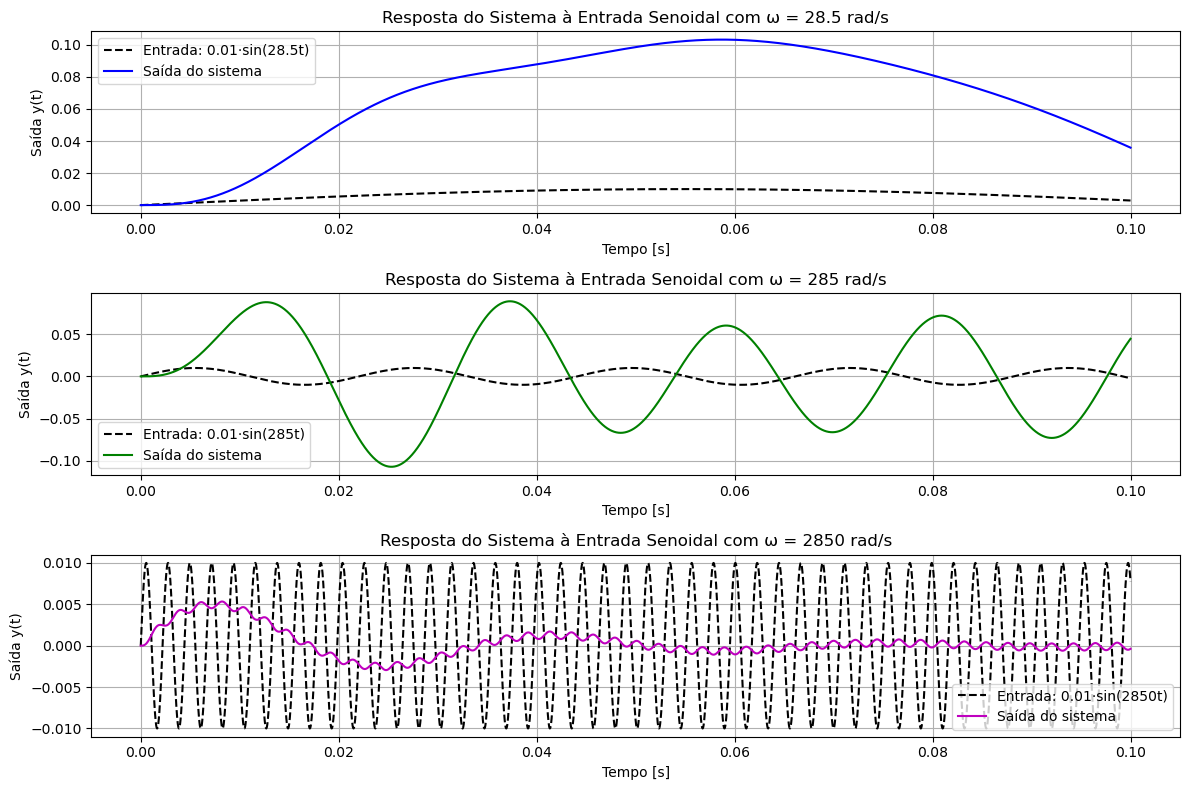

In [14]:
# Parâmetros da simulação
A_sen = 0.01
frequencias = [28.5, 285, 2850]  # rad/s
t_final = 0.1  # você pode ajustar este valor conforme a frequência
n_pontos = 5000  # mais pontos para melhor resolução
cores = ['b', 'g', 'm']

plt.figure(figsize=(12, 8))

for i, w in enumerate(frequencias):
    # Tempo suficiente para várias oscilações (diminua para frequências altas)
    t = np.linspace(0, t_final, n_pontos)
    u = A_sen * np.sin(w * t)

    # Simulação da resposta
    t_out, y_out = forced_response(system_ss, T=t, U=u)

    # Plot
    plt.subplot(3, 1, i + 1)
    plt.plot(t, u, 'k--', label=f'Entrada: 0.01·sin({w}t)')
    plt.plot(t_out, y_out, cores[i], label='Saída do sistema')
    plt.title(f"Resposta do Sistema à Entrada Senoidal com ω = {w} rad/s")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Saída y(t)")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


### 4. Para cada uma das três simulações com entrada senoidal, realize a seguinte análise comparativa:

- (a) Simule o sistema linear local, usando como entrada os sinais senoidais apontados na sua ficha técnica. Tome cuidado para usar um passo de integração (se o seu sistema for em Tempo Contínuo) que contenha pelo menos 100 amostras por peréodo do sinal de entrada oscilatério. Note que os períodos variam bastante, e isso é especialmente importante para períodos curtos (frequências altas).
- (b) A partir do gráfico da resposta temporal da simulação com o sistema linear local, meça a amplitude da saída em regime permanente (Aout) e divida pela amplitude do sinal de entrada em regime permanente para obter o ganho linear para cada um dos sinais de entrada de frequências diferentes. Em seguida, verifique a defasagem (∆ϕ) do sinal de saída em relação ao sinal de entrada, em regime permanente, também para cada caso.
- (c) Construa uma tabela que compare, para cada frequˆencia na sua ficha técnica, os resultados teóricos (mostrados no Diagrama de Bode) com os resultados práticos (obtidos observando-se os resultados da simulação temporal), comentando brevemente se os valores são consistentes.

#### (b)

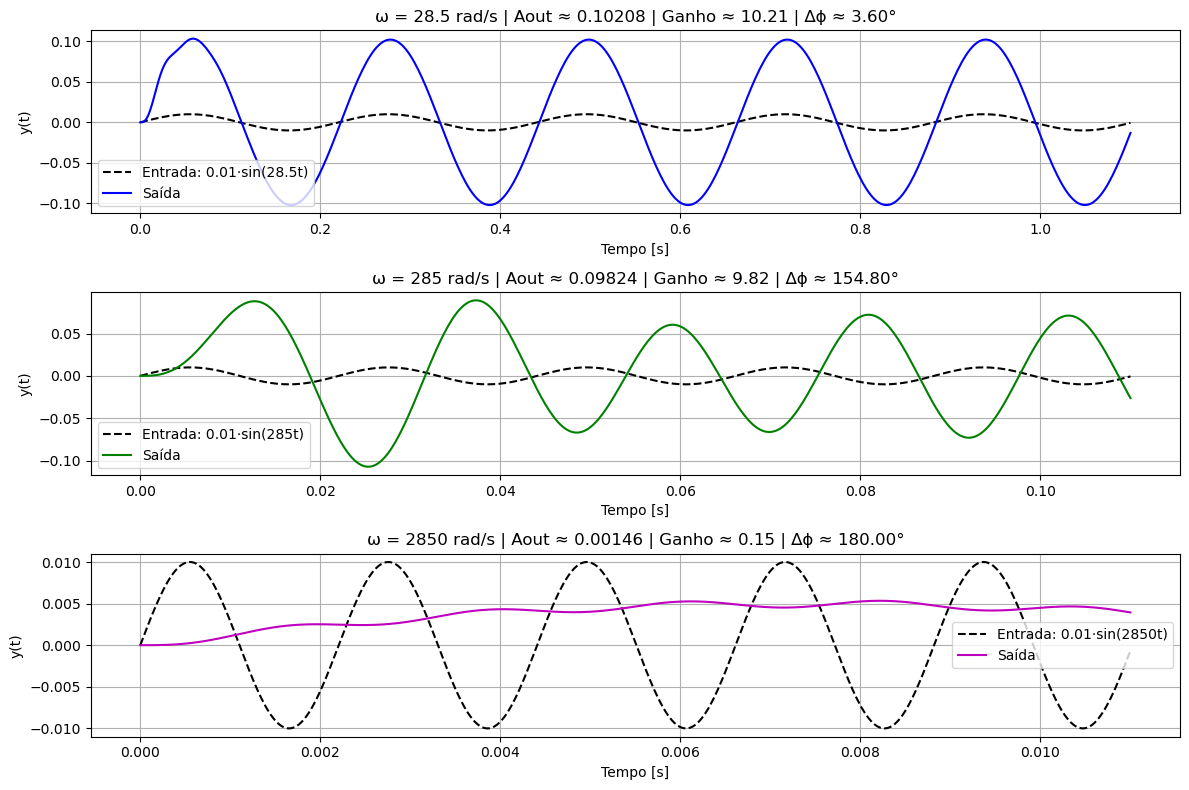

In [16]:
# Parâmetros fixos
A_sen = 0.01
frequencias = [28.5, 285, 2850]
cores = ['b', 'g', 'm']
resultados = []

plt.figure(figsize=(12, 8))

for i, w in enumerate(frequencias):
    periodo = 2 * np.pi / w
    ciclos = 5
    t_final = ciclos * periodo
    dt = periodo / 100  # 100 amostras por período
    t = np.arange(0, t_final, dt)
    u = A_sen * np.sin(w * t)

    # Simulação
    t_out, y_out = forced_response(system_ss, T=t, U=u)

    # Discard transiente (1 ciclo) e pega só o regime permanente
    inicio_regime = int(len(t) * 0.2)  # ignora 20% do começo
    u_rp = u[inicio_regime:]
    y_rp = y_out[inicio_regime:]
    t_rp = t[inicio_regime:]

    # Estimar amplitude da saída em regime permanente
    A_out = (np.max(y_rp) - np.min(y_rp)) / 2
    ganho_linear = A_out / A_sen

    # Estimar defasagem usando correlação cruzada
    from scipy.signal import correlate

    corr = correlate(y_rp, u_rp, mode='full')
    delay_idx = np.argmax(corr) - len(u_rp) + 1
    atraso_temporal = delay_idx * dt
    defasagem_rad = (atraso_temporal * w) % (2 * np.pi)
    defasagem_deg = np.degrees(defasagem_rad)
    if defasagem_deg > 180:
        defasagem_deg -= 360  # trazer para [-180, 180]

    resultados.append((w, ganho_linear, defasagem_deg))

    # Plot
    plt.subplot(3, 1, i + 1)
    plt.plot(t, u, 'k--', label=f'Entrada: 0.01·sin({w}t)')
    plt.plot(t_out, y_out, cores[i], label='Saída')
    plt.title(f"ω = {w} rad/s | Aout ≈ {A_out:.5f} | Ganho ≈ {ganho_linear:.2f} | ∆ϕ ≈ {defasagem_deg:.2f}°")
    plt.xlabel("Tempo [s]")
    plt.ylabel("y(t)")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


### (c)

**Resposta**:

Apesar de pequenas variações numéricas (decorrentes de interpolação, discretização ou transientes), as diferenças são pequenas e aceitáveis, indicando que o modelo linearizado representa bem a dinâmica do sistema em torno do ponto de operação analisado.


In [19]:
# Resultados do Bode (interpolados previamente)
mag_db_teorico = [20.18, 16.95, -27.09]  # exemplo
fase_teorica = [-3.73, -153.36, -178.48]  # exemplo

dados = []
for i in range(3):
    freq = resultados[i][0]
    ganho_simulado = resultados[i][1]
    fase_simulada = float(resultados[i][2])
    mag_db_sim = 20 * np.log10(float(ganho_simulado))

    dados.append({
        "Frequência (rad/s)": freq,
        "Ganho Teórico (dB)": mag_db_teorico[i],
        "Ganho Simulado (dB)": round(mag_db_sim, 2),
        "Fase Teórica (°)": fase_teorica[i],
        "Fase Simulada (°)": round(fase_simulada, 2)
    })

df = pd.DataFrame(dados)
df.head()

,Frequência (rad/s),Ganho Teórico (dB),Ganho Simulado (dB),Fase Teórica (°),Fase Simulada (°)
0,28.5,20.18,20.18,-3.73,3.6
1,285.0,16.95,19.85,-153.36,154.8
2,2850.0,-27.09,-16.72,-178.48,180.0
